In [2]:
# Install YOLO
!pip install ultralytics

from ultralytics import YOLO
from PIL import Image
import requests
from io import BytesIO

# Load pretrained YOLO model
model = YOLO("yolov8n.pt")

# Load sample image
url = "https://ultralytics.com/images/bus.jpg"
img = Image.open(BytesIO(requests.get(url).content))

# Run detection
results = model(img)

# Save output
results[0].save(filename="detection_output.jpg")

print("YOLO output saved!")


0: 640x480 4 persons, 1 bus, 1 stop sign, 197.4ms
Speed: 12.1ms preprocess, 197.4ms inference, 5.8ms postprocess per image at shape (1, 3, 640, 480)
YOLO output saved!


# New Section

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:02<00:00, 79.6MB/s]


Segmentation output saved!


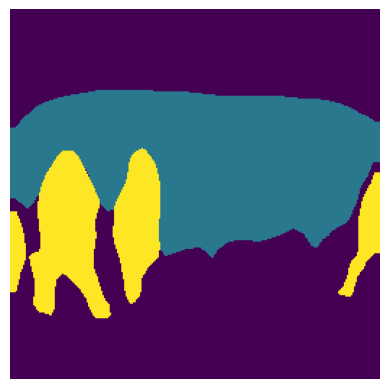

In [3]:
# Install required libraries
!pip install torch torchvision matplotlib pillow

import torch
from torchvision import models
from PIL import Image
import requests
from io import BytesIO
import torchvision.transforms as T
import matplotlib.pyplot as plt

# Load pretrained DeepLab model
model = models.segmentation.deeplabv3_resnet50(pretrained=True)
model.eval()

# Load same image
url = "https://ultralytics.com/images/bus.jpg"
img = Image.open(BytesIO(requests.get(url).content)).convert("RGB")

# Transform image
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor()
])

input_tensor = transform(img).unsqueeze(0)

# Run segmentation
with torch.no_grad():
    output = model(input_tensor)['out'][0]

# Get segmentation map
pred = output.argmax(0)

# Save result
plt.imshow(pred.cpu())
plt.axis("off")
plt.savefig("segmentation_output.png")

print("Segmentation output saved!")